# XGBoost SMARD + Weather Models

This notebook rebuilds the XGBoost workflow around two reportable models on the common forecast-data window:

- `past_model`: uses only historical observed weather, SMARD, and price lags.
- `forecast_model`: replaces target-window weather inputs with Open-Meteo previous-runs day-1 forecast regional features.

Both models use the same target timestamps, split boundaries, feature grouping logic, ablation workflow, pruning workflow, tuning workflow, and final test evaluation.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

warnings.filterwarnings("ignore", category=UserWarning)


## Load Regional Weather and SMARD Data


In [2]:
RAW_DATA_DIR = Path("../raw_data")
PROCESSED_DATA_DIR = Path("../processed_data")

SMARD_PATH = RAW_DATA_DIR / "Combined_smard_data.csv"
OBSERVED_WEATHER_PATH = (
    PROCESSED_DATA_DIR
    / "Open_Meteo_regional_features_2019-05-01_to_2026-05-01.csv"
)
FORECAST_WEATHER_PATH = (
    PROCESSED_DATA_DIR
    / "Open_Meteo_previous_runs_day1_regional_features_2024-03-01_to_2026-05-02.csv"
)

FORECAST_START = pd.Timestamp("2024-03-01", tz="UTC")
FORECAST_END_EXCLUSIVE = pd.Timestamp("2026-05-03", tz="UTC")
VALID_START = pd.Timestamp("2025-07-01", tz="UTC")
TEST_START = pd.Timestamp("2025-12-01", tz="UTC")

HISTORICAL_LAGS = [24, 48, 168]
FORECAST_WEATHER_LAGS = [0, 1, 24]
MODEL_RANDOM_STATE = 42
ENABLE_GPU = True


In [3]:
REGION_FEATURE_SPECS = {
    "north_wind": [
        "wind_speed_100m_avg",
        "wind_direction_100m_sin_avg",
        "wind_direction_100m_cos_avg",
    ],
    "northeast_wind": [
        "wind_speed_100m_avg",
        "wind_direction_100m_sin_avg",
        "wind_direction_100m_cos_avg",
    ],
    "offshore_north_sea": [
        "wind_speed_100m_avg",
        "wind_direction_100m_sin_avg",
        "wind_direction_100m_cos_avg",
    ],
    "offshore_baltic_sea": [
        "wind_speed_100m_avg",
        "wind_direction_100m_sin_avg",
        "wind_direction_100m_cos_avg",
    ],
    "south_solar": [
        "solar_radiation_avg",
        "cloud_cover_avg",
        "sunshine_duration_avg",
    ],
    "east_solar": [
        "solar_radiation_avg",
        "cloud_cover_avg",
        "sunshine_duration_avg",
    ],
    "west_solar_load": ["temperature_2m_avg", "cloud_cover_avg"],
}


In [4]:
def load_regional_weather(path, region_specs=REGION_FEATURE_SPECS):
    weather = pd.read_csv(path, parse_dates=["timestamp_utc"]).sort_values(["timestamp_utc", "region"])
    missing_regions = sorted(set(region_specs) - set(weather["region"].dropna().unique()))
    if missing_regions:
        raise ValueError(f"{path.name} is missing regions: {missing_regions}")

    parts = []
    for region, columns in region_specs.items():
        region_data = weather.loc[weather["region"].eq(region)]
        duplicate_count = region_data["timestamp_utc"].duplicated().sum()
        if duplicate_count:
            raise ValueError(f"{path.name}: {region} has duplicate timestamps")
        parts.append(
            region_data.set_index("timestamp_utc")[columns]
            .sort_index()
            .add_prefix(f"{region}__")
        )

    regional_weather = pd.concat(parts, axis=1).sort_index()
    if not regional_weather.index.is_unique:
        raise ValueError(f"{path.name}: wide weather index is not unique")
    return regional_weather


In [5]:
observed_weather = load_regional_weather(OBSERVED_WEATHER_PATH)
forecast_weather = load_regional_weather(FORECAST_WEATHER_PATH)

weather_feature_columns = observed_weather.columns.tolist()
display({
    "observed_shape": observed_weather.shape,
    "forecast_shape": forecast_weather.shape,
    "features_only_in_observed": sorted(set(observed_weather.columns) - set(forecast_weather.columns)),
    "features_only_in_forecast": sorted(set(forecast_weather.columns) - set(observed_weather.columns)),
})


{'observed_shape': (61392, 20),
 'forecast_shape': (19032, 20),
 'features_only_in_observed': [],
 'features_only_in_forecast': []}

In [6]:
smard = pd.read_csv(SMARD_PATH, parse_dates=["Start_date"])
first_repeated_hour = smard["Start_date"].duplicated(keep="last")
smard["timestamp_utc"] = (
    smard["Start_date"]
    .dt.tz_localize(
        "Europe/Berlin",
        ambiguous=first_repeated_hour.to_numpy(),
        nonexistent="raise",
    )
    .dt.tz_convert("UTC")
)
smard = smard.drop(columns="Start_date").set_index("timestamp_utc").sort_index()
smard = smard.drop(columns=["Nuclear"], errors="ignore")

assert smard.index.is_unique
assert smard.index.is_monotonic_increasing

display({"smard_shape": smard.shape, "start": smard.index.min(), "end": smard.index.max()})


{'smard_shape': (61374, 20),
 'start': Timestamp('2019-04-30 22:00:00+0000', tz='UTC'),
 'end': Timestamp('2026-05-01 03:00:00+0000', tz='UTC')}

## Feature Engineering


In [7]:
local_time = smard.index.tz_convert("Europe/Berlin")
calendar_features = pd.DataFrame(index=smard.index)
calendar_features["Hour"] = local_time.hour
calendar_features["Day_of_week"] = local_time.dayofweek
calendar_features["Month"] = local_time.month
calendar_features["Is_weekend"] = (local_time.dayofweek >= 5).astype(int)
calendar_features["Hour_sin"] = np.sin(2 * np.pi * calendar_features["Hour"] / 24)
calendar_features["Hour_cos"] = np.cos(2 * np.pi * calendar_features["Hour"] / 24)

time_features = calendar_features.columns.tolist()


In [8]:
smard_lag_sources = [
    "Biomass", "Hydro", "Wind_offshore", "Wind_onshore", "Photovolt",
    "Other_ren", "Lignite", "Hard_coal", "Fossil_gas",
    "Hydro_pump_stor", "Other_conv", "Total_gen", "Residuals",
]
price_sources = ["Price"]


def select_lags(base_columns, selected_lags):
    selected_lags = list(dict.fromkeys(selected_lags))
    selected_columns = list(base_columns) if 0 in selected_lags else []
    selected_columns += [
        f"{column}_lag_{lag}"
        for lag in selected_lags if lag != 0
        for column in base_columns
    ]
    return selected_columns


def build_lagged_features(frame, selected_lags):
    parts = []
    if 0 in selected_lags:
        parts.append(frame.copy())
    parts.extend(
        frame.shift(lag).add_suffix(f"_lag_{lag}")
        for lag in selected_lags if lag != 0
    )
    return pd.concat(parts, axis=1)


In [9]:
renewable_smard = {"Biomass", "Hydro", "Wind_offshore", "Wind_onshore", "Photovolt", "Other_ren"}
non_renewable_smard = {"Lignite", "Hard_coal", "Fossil_gas", "Other_conv"}
system_level_smard = {"Total_gen", "Residuals"}
system_auxiliary_smard = {"Hydro_pump_stor"}
calendar_feature_set = set(time_features)

# builds feature groups for feature pruning
def feature_category(feature):
    base = feature.rsplit("_lag_", 1)[0]
    if base in calendar_feature_set:
        return "Calendar"
    if base == "Price":
        return "Price history"
    if base.startswith(("north_wind__", "northeast_wind__", "offshore_")):
        return "Weather: wind"
    if base.startswith(("south_solar__", "east_solar__")):
        return "Weather: solar"
    if base.startswith("west_solar_load__"):
        return "Weather: load proxy"
    if base in renewable_smard:
        return "SMARD: Renewable"
    if base in non_renewable_smard:
        return "SMARD: Non-renewable"
    if base in system_level_smard:
        return "SMARD: System level"
    if base in system_auxiliary_smard:
        return "SMARD: System auxiliary"
    return "Other"


def summarize_importance_by_group(importance_df, title):
    grouped_features = importance_df.copy()
    grouped_features["category"] = grouped_features["feature"].map(feature_category)
    grouped_features["lag"] = grouped_features["feature"].str.extract(r"_lag_(\d+)$")[0].fillna("0")
    grouped_features.loc[grouped_features["category"] == "Calendar", "lag"] = "target"

    summary = grouped_features.groupby(["category", "lag"], as_index=False).agg(
        feature_count=("feature", "size"),
        total_importance=("importance_mean", "sum"),
        mean_importance=("importance_mean", "mean"),
        positive_share=("importance_mean", lambda values: (values > 0).mean()),
    )
    summary = summary.sort_values("total_importance", ascending=False)
    display(summary)

    lag_order = [lag for lag in ["0", "1", "24", "48", "168", "target"] if lag in summary["lag"].values]
    heatmap_data = summary.pivot(index="category", columns="lag", values="mean_importance").reindex(columns=lag_order)
    plt.figure(figsize=(11, 6))
    sns.heatmap(heatmap_data, cmap="RdBu_r", center=0, annot=True, fmt=".4f")
    plt.title(title)
    plt.xlabel("Lag (hours)")
    plt.ylabel("Feature category")
    plt.tight_layout()
    plt.show()
    return summary, heatmap_data


In [10]:
smard_lagged = build_lagged_features(smard[smard_lag_sources], HISTORICAL_LAGS)
price_lagged = build_lagged_features(smard[price_sources], HISTORICAL_LAGS)
observed_weather_lagged = build_lagged_features(observed_weather[weather_feature_columns], HISTORICAL_LAGS)
forecast_weather_lagged = build_lagged_features(forecast_weather[weather_feature_columns], FORECAST_WEATHER_LAGS)

base_features = pd.concat(
    [calendar_features, smard_lagged, price_lagged, smard[["Negative_price"]]],
    axis=1,
)

past_weather_features = select_lags(weather_feature_columns, HISTORICAL_LAGS)
forecast_weather_features = select_lags(weather_feature_columns, FORECAST_WEATHER_LAGS)
smard_features = select_lags(smard_lag_sources, HISTORICAL_LAGS)
price_history = select_lags(price_sources, HISTORICAL_LAGS)

past_feature_cols = time_features + past_weather_features + smard_features + price_history
forecast_feature_cols = time_features + forecast_weather_features + smard_features + price_history

past_data = (
    base_features.join(observed_weather_lagged, how="inner")
    [past_feature_cols + ["Negative_price"]]
    .dropna()
)
forecast_data = (
    base_features.join(forecast_weather_lagged, how="inner")
    [forecast_feature_cols + ["Negative_price"]]
    .dropna()
)

common_index = past_data.index.intersection(forecast_data.index)
common_index = common_index[
    (common_index >= FORECAST_START) & (common_index < FORECAST_END_EXCLUSIVE)
]
past_data = past_data.loc[common_index].dropna()
forecast_data = forecast_data.loc[common_index].dropna()
common_index = past_data.index.intersection(forecast_data.index)
past_data = past_data.loc[common_index]
forecast_data = forecast_data.loc[common_index]

assert past_data["Negative_price"].equals(forecast_data["Negative_price"])

data_window_summary = pd.DataFrame([
    {
        "dataset": "common_model_window",
        "start": common_index.min(),
        "end": common_index.max(),
        "hours": len(common_index),
        "negative_price_hours": int(past_data["Negative_price"].sum()),
        "positive_rate": past_data["Negative_price"].mean(),
        "past_features": len(past_feature_cols),
        "forecast_features": len(forecast_feature_cols),
    }
])
display(data_window_summary)


,dataset,start,end,hours,negative_price_hours,positive_rate,past_features,forecast_features
0,common_model_window,2024-03-02 00:00:00+00:00,2026-05-01 03:00:00+00:00,18964,1175,0.06196,108,108


## Chronological Train / Validation / Test Split


In [11]:
def split_model_data(model_data, feature_cols):
    X = model_data[feature_cols]
    y = model_data["Negative_price"].astype(int)
    splits = {
        "train": X.index < VALID_START,
        "validation": (X.index >= VALID_START) & (X.index < TEST_START),
        "test": X.index >= TEST_START,
    }
    return {
        name: (X.loc[mask], y.loc[mask])
        for name, mask in splits.items()
    }

past_splits = split_model_data(past_data, past_feature_cols)
forecast_splits = split_model_data(forecast_data, forecast_feature_cols)

split_summary = pd.DataFrame([
    {
        "split": name,
        "start": y.index.min(),
        "end": y.index.max(),
        "hours": len(y),
        "negative_price_hours": int(y.sum()),
        "positive_rate": y.mean(),
    }
    for name, (_, y) in past_splits.items()
]).set_index("split")
display(split_summary)


,start,end,hours,negative_price_hours,positive_rate
split,,,,,
train,2024-03-02 00:00:00+00:00,2025-06-30 23:00:00+00:00,11664,826,0.070816
validation,2025-07-01 00:00:00+00:00,2025-11-30 23:00:00+00:00,3672,184,0.050109
test,2025-12-01 00:00:00+00:00,2026-05-01 03:00:00+00:00,3628,165,0.045480


## Helpers


In [12]:
def scale_pos_weight(y):
    positives = int((y == 1).sum())
    negatives = int((y == 0).sum())
    if positives == 0:
        raise ValueError("Training target has no positive examples")
    return negatives / positives

# Default CPU setting. To try GPU, change this to {"tree_method": "hist", "device": "cuda"}.
XGB_DEVICE_PARAMS = {"tree_method": "hist"}


def make_xgb_classifier(y_train, params=None, n_jobs=4, n_estimators=300):
    params = params or {}
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        n_estimators=n_estimators,
        learning_rate=0.05,
        subsample=0.8,
        scale_pos_weight=scale_pos_weight(y_train),
        random_state=MODEL_RANDOM_STATE,
        n_jobs=n_jobs,
        **XGB_DEVICE_PARAMS,
        **params,
    )


def optimize_f1_threshold(y_true, probabilities, title):
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-10)
    best_index = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_index]
    best_f1 = f1_scores[best_index]

    print(f"Best F1: {best_f1:.4f} at threshold: {best_threshold:.4f}")
    print(classification_report(y_true, probabilities >= best_threshold, digits=4))

    pr_auc = average_precision_score(y_true, probabilities)
    pr_title = title.replace("F1 vs threshold", "PR curve")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(thresholds, f1_scores[:-1])
    axes[0].axvline(best_threshold, color="red", linestyle="--", label=f"Best F1 = {best_f1:.3f}")
    axes[0].set(xlabel="Probability threshold", ylabel="F1 score", title=title)
    axes[0].legend()
    axes[0].grid(alpha=0.2)

    axes[1].plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
    axes[1].axhline(y_true.mean(), color="gray", linestyle="--", label="Positive-rate baseline")
    axes[1].set(xlabel="Recall", ylabel="Precision", title=pr_title)
    axes[1].legend()
    axes[1].grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
    return best_threshold, best_f1


def evaluate_probabilities(model_name, y_true, probabilities, threshold=0.5):
    return {
        "model": model_name,
        "threshold": threshold,
        "F1": f1_score(y_true, probabilities >= threshold),
        "PR_AUC": average_precision_score(y_true, probabilities),
        "ROC_AUC": roc_auc_score(y_true, probabilities),
        "positive_rate": y_true.mean(),
    }


In [13]:
display({"xgb_device_params": XGB_DEVICE_PARAMS})


{'xgb_device_params': {'tree_method': 'hist'}}

## Baseline Models


In [14]:
X_train_past, y_train_past = past_splits["train"]
X_valid_past, y_valid_past = past_splits["validation"]
X_test_past, y_test_past = past_splits["test"]

X_train_forecast, y_train_forecast = forecast_splits["train"]
X_valid_forecast, y_valid_forecast = forecast_splits["validation"]
X_test_forecast, y_test_forecast = forecast_splits["test"]

past_model = make_xgb_classifier(y_train_past).fit(X_train_past, y_train_past)
forecast_model = make_xgb_classifier(y_train_forecast).fit(X_train_forecast, y_train_forecast)

y_valid_prob_past = past_model.predict_proba(X_valid_past)[:, 1]
y_valid_prob_forecast = forecast_model.predict_proba(X_valid_forecast)[:, 1]

baseline_validation = pd.DataFrame([
    evaluate_probabilities("past_model", y_valid_past, y_valid_prob_past),
    evaluate_probabilities("forecast_model", y_valid_forecast, y_valid_prob_forecast),
]).set_index("model")
display(baseline_validation)


,threshold,F1,PR_AUC,ROC_AUC,positive_rate
model,,,,,
past_model,0.5,0.483871,0.431968,0.919243,0.050109
forecast_model,0.5,0.585480,0.631364,0.964468,0.050109


Best F1: 0.5000 at threshold: 0.6365
              precision    recall  f1-score   support

           0     0.9749    0.9693    0.9721      3488
           1     0.4755    0.5272    0.5000       184

    accuracy                         0.9472      3672
   macro avg     0.7252    0.7482    0.7361      3672
weighted avg     0.9499    0.9472    0.9485      3672



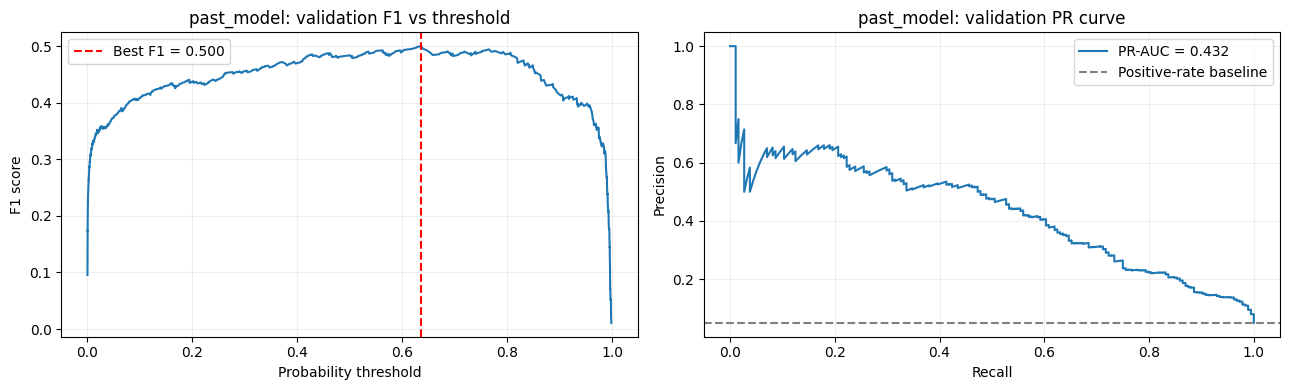

Best F1: 0.5902 at threshold: 0.6084
              precision    recall  f1-score   support

           0     0.9817    0.9699    0.9758      3488
           1     0.5354    0.6576    0.5902       184

    accuracy                         0.9542      3672
   macro avg     0.7586    0.8138    0.7830      3672
weighted avg     0.9594    0.9542    0.9565      3672



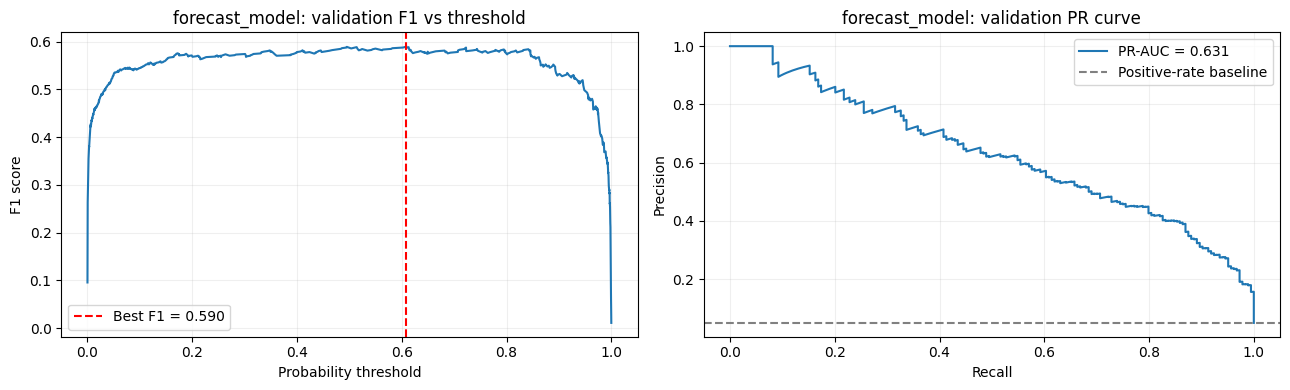

In [15]:
best_threshold_past, best_f1_past = optimize_f1_threshold(
    y_valid_past,
    y_valid_prob_past,
    "past_model: validation F1 vs threshold",
)
best_threshold_forecast, best_f1_forecast = optimize_f1_threshold(
    y_valid_forecast,
    y_valid_prob_forecast,
    "forecast_model: validation F1 vs threshold",
)


## Group Permutation Importance


In [16]:
def group_permutation_importance(model, X_valid, y_valid, title):
    permutation_result = permutation_importance(
        model,
        X_valid,
        y_valid,
        scoring="average_precision",
        n_repeats=10,
        random_state=MODEL_RANDOM_STATE,
        n_jobs=4,
    )
    permutation_df = pd.DataFrame({
        "feature": X_valid.columns,
        "importance_mean": permutation_result.importances_mean,
        "importance_std": permutation_result.importances_std,
    }).sort_values("importance_mean", ascending=False)
    summary, heatmap = summarize_importance_by_group(permutation_df, title)
    return permutation_df, summary, heatmap



,category,lag,feature_count,total_importance,mean_importance,positive_share
0,Calendar,target,6,0.122027,0.020338,0.500000
2,Price history,24,1,0.101953,0.101953,1.000000
5,SMARD: Non-renewable,24,4,0.028942,0.007235,0.750000
9,SMARD: Renewable,48,6,0.024618,0.004103,0.333333
19,Weather: solar,168,6,0.017093,0.002849,0.666667
4,SMARD: Non-renewable,168,4,0.011809,0.002952,0.750000
14,SMARD: System level,24,2,0.011096,0.005548,1.000000
17,Weather: load proxy,24,2,0.007183,0.003591,0.500000
13,SMARD: System level,168,2,0.006439,0.003220,1.000000
8,SMARD: Renewable,24,6,0.001420,0.000237,0.666667


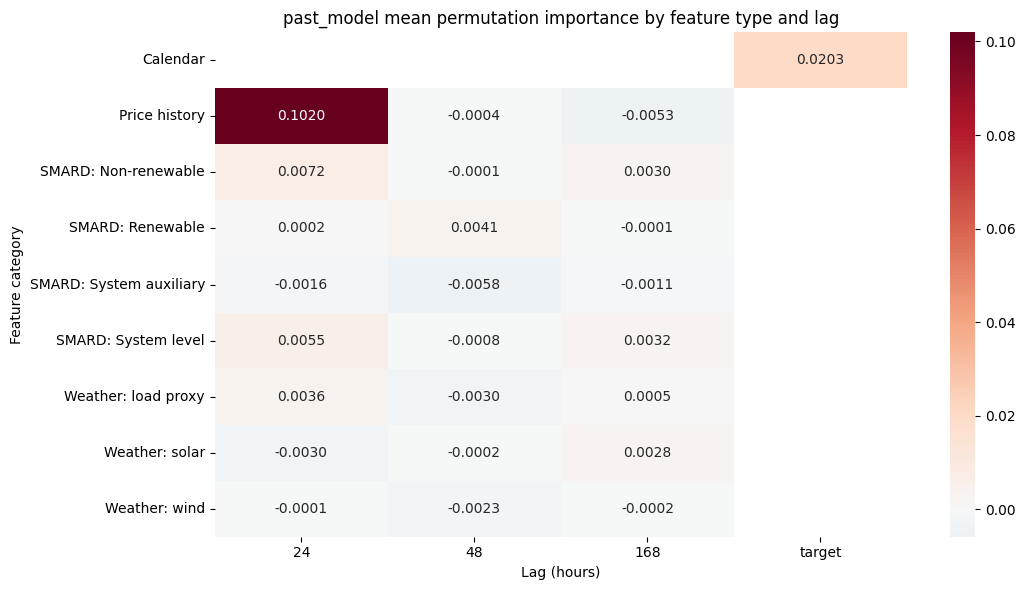

In [17]:
# past model
past_permutation_df, past_importance_summary, past_importance_heatmap = group_permutation_importance(
    past_model,
    X_valid_past,
    y_valid_past,
    "past_model mean permutation importance by feature type and lag",
)


,category,lag,feature_count,total_importance,mean_importance,positive_share
0,Calendar,target,6,0.146277,0.024380,0.500000
22,Weather: wind,0,12,0.119316,0.009943,0.833333
23,Weather: wind,1,12,0.067915,0.005660,0.916667
19,Weather: solar,0,6,0.031792,0.005299,0.833333
2,Price history,24,1,0.020688,0.020688,1.000000
9,SMARD: Renewable,48,6,0.016535,0.002756,0.500000
7,SMARD: Renewable,168,6,0.013837,0.002306,0.666667
18,Weather: load proxy,24,2,0.013155,0.006577,0.500000
12,SMARD: System auxiliary,48,1,0.008211,0.008211,1.000000
16,Weather: load proxy,0,2,0.007469,0.003734,1.000000


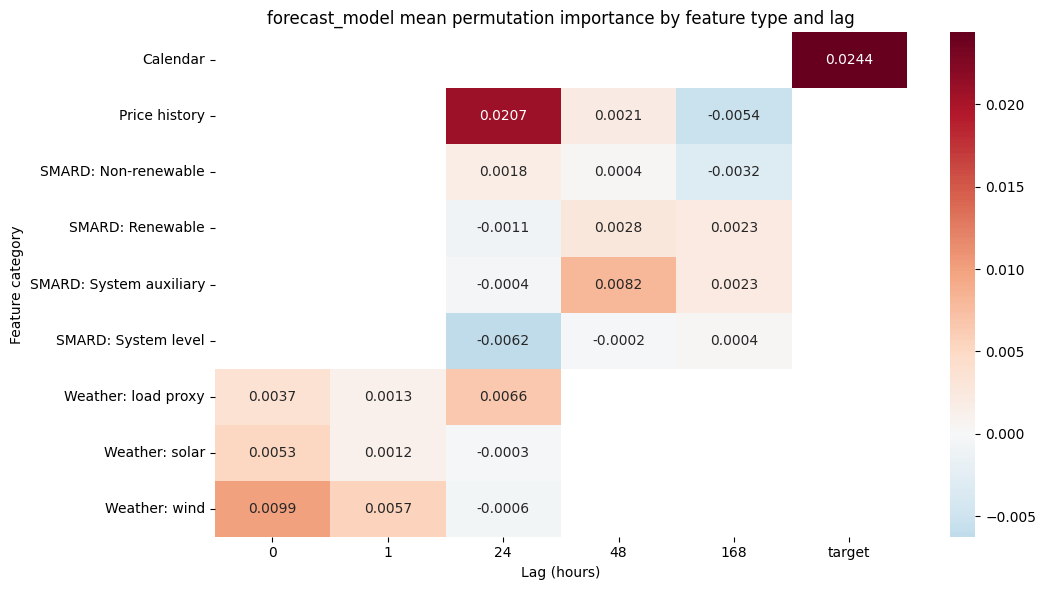

In [18]:
# forecast model
forecast_permutation_df, forecast_importance_summary, forecast_importance_heatmap = group_permutation_importance(
    forecast_model,
    X_valid_forecast,
    y_valid_forecast,
    "forecast_model mean permutation importance by feature type and lag",
)


We observe that:
* weather forecast within 24 hours seems to be useful, compared to having only weather data before 24 hours.
* SMARD residual and total_gen are not useful, probably because they are overlapping with other smard data 
* lag = 168 are on average not useful.

## Forecast Model Ablation Tests


,PR_AUC,Delta_vs_full
Full model,0.631364,0.000000
No SMARD system level,0.639884,0.008520
No lag 168,0.666499,0.035135
No SMARD system level + lag 168,0.668097,0.036732


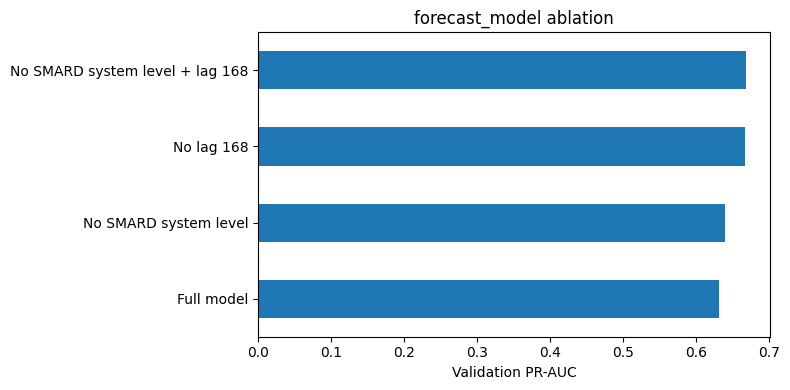

In [19]:
forecast_smard_system_level_features = {
    column
    for column in forecast_feature_cols
    if column.rsplit("_lag_", 1)[0] in {"Total_gen", "Residuals"}
}
forecast_lag_168_features = {
    column
    for column in forecast_feature_cols
    if column.endswith("_lag_168")
}

forecast_ablation_groups = {
    "Full model": set(),
    "No SMARD system level": forecast_smard_system_level_features,
    "No lag 168": forecast_lag_168_features,
    "No SMARD system level + lag 168": (
        forecast_smard_system_level_features | forecast_lag_168_features
    ),
}

forecast_ablation_scores = {}
for name, removed_features in forecast_ablation_groups.items():
    columns = [column for column in forecast_feature_cols if column not in removed_features]
    fitted = XGBClassifier(**forecast_model.get_params()).fit(
        X_train_forecast[columns],
        y_train_forecast,
    )
    forecast_ablation_scores[name] = average_precision_score(
        y_valid_forecast,
        fitted.predict_proba(X_valid_forecast[columns])[:, 1],
    )

forecast_ablation = pd.Series(
    forecast_ablation_scores,
    name="PR_AUC",
).to_frame()
forecast_ablation["Delta_vs_full"] = (
    forecast_ablation["PR_AUC"] - forecast_ablation.loc["Full model", "PR_AUC"]
)
display(forecast_ablation)

forecast_ablation["PR_AUC"].plot.barh(figsize=(8, 4))
plt.xlabel("Validation PR-AUC")
plt.title("forecast_model ablation")
plt.tight_layout()
plt.show()


Based on this test we decide to prune both. We will proceed with forecast_model only from now on.

## Pruned Feature Sets


In [20]:
forecast_removed = forecast_smard_system_level_features | forecast_lag_168_features
forecast_feature_cols_pruned = [
    column
    for column in forecast_feature_cols
    if column not in forecast_removed
]

display({
    "forecast_model": {
        "before": len(forecast_feature_cols),
        "after": len(forecast_feature_cols_pruned),
        "removed": len(forecast_removed),
    },
})


{'forecast_model': {'before': 108, 'after': 90, 'removed': 18}}

In [21]:
forecast_model_pruned = make_xgb_classifier(y_train_forecast).fit(
    X_train_forecast[forecast_feature_cols_pruned],
    y_train_forecast,
)

y_valid_prob_forecast_pruned = forecast_model_pruned.predict_proba(
    X_valid_forecast[forecast_feature_cols_pruned]
)[:, 1]

pruned_validation = pd.DataFrame([
    evaluate_probabilities("forecast_model original", y_valid_forecast, y_valid_prob_forecast),
    evaluate_probabilities("forecast_model pruned", y_valid_forecast, y_valid_prob_forecast_pruned),
]).set_index("model")
display(pruned_validation)


,threshold,F1,PR_AUC,ROC_AUC,positive_rate
model,,,,,
forecast_model original,0.5,0.585480,0.631364,0.964468,0.050109
forecast_model pruned,0.5,0.615385,0.668097,0.972748,0.050109


## Hyperparameter Tuning
Hyperparameters were selected through iterative validation experiments using grid search. The final search focused on tree depth, minimum child weight, and feature subsampling, with validation PR-AUC as the selection metric.

In [22]:
time_cv = TimeSeriesSplit(n_splits=3)


forecast_param_grid = {
    "max_depth": [8, 10, 12],
    "min_child_weight": [1, 2],
    "colsample_bytree": [0.1, 0.3, 0.5],
}


def tune_xgboost(X_train, y_train, param_grid):
    estimator = make_xgb_classifier(
        y_train,
        n_jobs=1,
        n_estimators=300,
    )
    search = GridSearchCV(
        estimator,
        param_grid,
        scoring="average_precision",
        cv=time_cv,
        n_jobs=4,
        refit=True,
        return_train_score=False,
    )
    return search.fit(X_train, y_train)

forecast_grid = tune_xgboost(
    X_train_forecast[forecast_feature_cols_pruned],
    y_train_forecast,
    forecast_param_grid,
)

print("forecast_model:", forecast_grid.best_params_, forecast_grid.best_score_)


forecast_model: {'colsample_bytree': 0.3, 'max_depth': 10, 'min_child_weight': 1} 0.5680075886238446


Best F1: 0.6190 at threshold: 0.5792
              precision    recall  f1-score   support

           0     0.9807    0.9779    0.9793      3488
           1     0.6031    0.6359    0.6190       184

    accuracy                         0.9608      3672
   macro avg     0.7919    0.8069    0.7992      3672
weighted avg     0.9618    0.9608    0.9613      3672



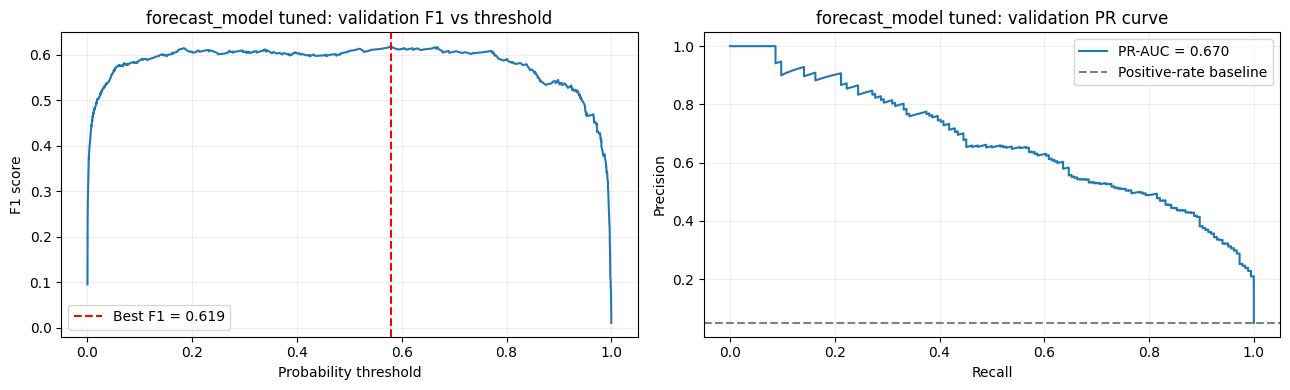

,threshold,F1,PR_AUC,ROC_AUC,positive_rate
model,,,,,
forecast_model pruned,0.500000,0.615385,0.668097,0.972748,0.050109
forecast_model tuned,0.579151,0.619048,0.670493,0.972574,0.050109


In [23]:

y_valid_prob_forecast_tuned = forecast_grid.best_estimator_.predict_proba(
    X_valid_forecast[forecast_feature_cols_pruned]
)[:, 1]


best_threshold_forecast_tuned, best_f1_forecast_tuned = optimize_f1_threshold(
    y_valid_forecast,
    y_valid_prob_forecast_tuned,
    "forecast_model tuned: validation F1 vs threshold",
)

tuned_validation = pd.DataFrame([
    evaluate_probabilities("forecast_model pruned", y_valid_forecast, y_valid_prob_forecast_pruned),
    evaluate_probabilities("forecast_model tuned", y_valid_forecast, y_valid_prob_forecast_tuned, best_threshold_forecast_tuned),
]).set_index("model")
display(tuned_validation)


## Write Feature Group to CSV

In [ ]:
FINALIZED_FEATURE_DATA_PATH = PROCESSED_DATA_DIR / "finalized_feature_data_2024-03-01_2026-05-02.csv"

final_smard_columns = [
    "Biomass",
    "Hydro",
    "Wind_offshore",
    "Wind_onshore",
    "Photovolt",
    "Other_ren",
    "Lignite",
    "Hard_coal",
    "Fossil_gas",
    "Hydro_pump_stor",
    "Other_conv",
    "Price",
    "Negative_price",
]
excluded_final_columns = {"Nuclear", "Nuclear_gap", "Total_gen", "Residuals"}
final_smard_columns = [column for column in final_smard_columns if column in smard.columns]

observed_weather_for_dl = observed_weather.add_prefix("observed_")
forecast_weather_for_dl = forecast_weather.add_prefix("forecast_")

finalized_feature_data = (
    calendar_features
    .join(smard[final_smard_columns], how="inner")
    .join(observed_weather_for_dl, how="inner")
    .join(forecast_weather_for_dl, how="inner")
    .sort_index()
)
finalized_feature_data = finalized_feature_data.loc[
    (finalized_feature_data.index >= FORECAST_START)
    & (finalized_feature_data.index < FORECAST_END_EXCLUSIVE)
]

blocked_columns = sorted(
    column for column in finalized_feature_data.columns
    if column in excluded_final_columns or "Nuclear" in column
)
if blocked_columns:
    raise ValueError(f"Finalized feature table still contains excluded columns: {blocked_columns}")
if finalized_feature_data.index.has_duplicates:
    raise ValueError("Finalized feature table has duplicated timestamps.")
if finalized_feature_data.isna().any().any():
    missing_counts = finalized_feature_data.isna().sum()
    raise ValueError(f"Finalized feature table contains missing values: {missing_counts[missing_counts > 0].to_dict()}")

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
finalized_feature_data.reset_index(names="timestamp_utc").to_csv(FINALIZED_FEATURE_DATA_PATH, index=False)

print(f"Wrote: {FINALIZED_FEATURE_DATA_PATH}")
print(f"Rows: {len(finalized_feature_data):,}")
print(f"Columns: {finalized_feature_data.shape[1] + 1:,}")
print(f"UTC range: {finalized_feature_data.index.min()} to {finalized_feature_data.index.max()}")
finalized_feature_data.head()

## Final Test Evaluation


In [ ]:
from typing import Any

def final_model(best_params, y_dev):
    return make_xgb_classifier(
        y_dev,
        params=best_params,
        n_jobs=4,
        n_estimators=300,
    )

X_dev_forecast = pd.concat([X_train_forecast, X_valid_forecast])[forecast_feature_cols_pruned]
y_dev_forecast = pd.concat([y_train_forecast, y_valid_forecast])

final_forecast_model = final_model(forecast_grid.best_params_, y_dev_forecast).fit(
    X_dev_forecast,
    y_dev_forecast,
)

y_test_prob_forecast = final_forecast_model.predict_proba(X_test_forecast[forecast_feature_cols_pruned])[:, 1]

test_evaluation = pd.DataFrame([
    evaluate_probabilities("forecast_model tuned", y_test_forecast, y_test_prob_forecast, best_threshold_forecast_tuned),
]).set_index("model")
display(test_evaluation)

for name, y_true, probabilities, threshold in [
    ("forecast_model tuned", y_test_forecast, y_test_prob_forecast, best_threshold_forecast_tuned),
]:
    print(f"\n{name} at validation-selected threshold {threshold:.4f}")
    print(classification_report(y_true, probabilities >= threshold, digits=4))


,threshold,F1,PR_AUC,ROC_AUC,positive_rate
model,,,,,
forecast_model tuned,0.579151,0.692607,0.864746,0.988719,0.04548



forecast_model tuned at validation-selected threshold 0.5792
              precision    recall  f1-score   support

           0     0.9785    0.9991    0.9887      3463
           1     0.9674    0.5394    0.6926       165

    accuracy                         0.9782      3628
   macro avg     0.9729    0.7693    0.8407      3628
weighted avg     0.9780    0.9782    0.9752      3628



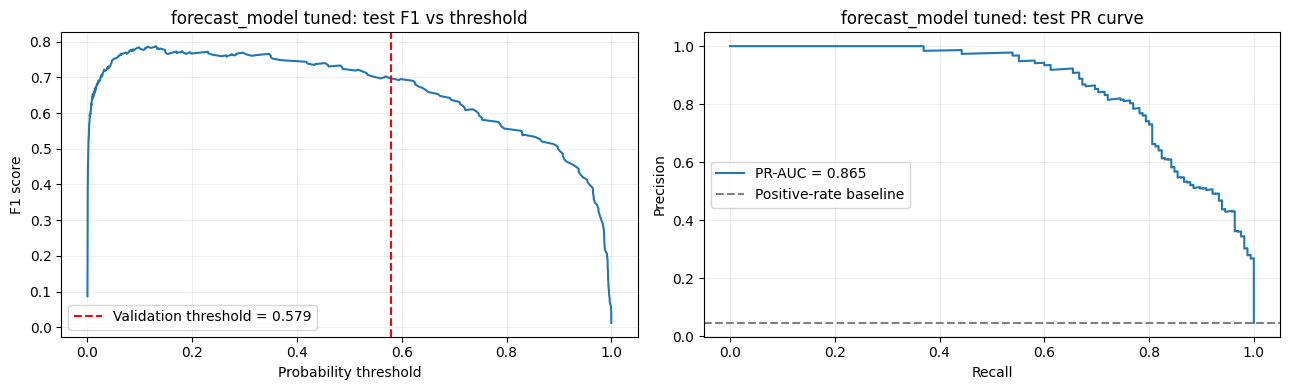

In [26]:
precision, recall, thresholds = precision_recall_curve(y_test_forecast, y_test_prob_forecast)
f1_scores = 2 * precision * recall / (precision + recall + 1e-10)
test_pr_auc = average_precision_score(y_test_forecast, y_test_prob_forecast)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(thresholds, f1_scores[:-1])
axes[0].axvline(
    best_threshold_forecast_tuned,
    color="red",
    linestyle="--",
    label=f"Validation threshold = {best_threshold_forecast_tuned:.3f}",
)
axes[0].set(
    xlabel="Probability threshold",
    ylabel="F1 score",
    title="forecast_model tuned: test F1 vs threshold",
)
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(recall, precision, label=f"PR-AUC = {test_pr_auc:.3f}")
axes[1].axhline(y_test_forecast.mean(), color="gray", linestyle="--", label="Positive-rate baseline")
axes[1].set(xlabel="Recall", ylabel="Precision", title="forecast_model tuned: test PR curve")
axes[1].legend()
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()
